**This is a workup on Module 2: Chemical Strucutures and representations**

**1. Install Openbabel and RDKit**

In [1]:
!pip install openbabel
!pip install rdkit


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


**2. Explore the functionality of Openbabel using the help option**

In [2]:
!obabel -H

Open Babel converts chemical structures from one file format to another

Usage: 
obabel[-i<input-type>] <infilename> [-o<output-type>] -O<outfilename> [Options]
The extension of a file decides the format, unless it is overridden
 by -i or -o options, e.g. -icml, or -o smi
See below for available format-types, which are the same as the 
file extensions and are case independent.
If no input or output file is given stdin or stdout are used instead.

More than one input file can be specified and their names can contain
wildcard chars (* and ?). The format of each file can be different unless
the -i option has been used, when they are all the same.
By default, the molecules are aggregated in the output file,
 but see -m option, Splitting, below.

Options, other than -i -o -O -m, must come after the input files.

Conversion options
-f <#> Start import at molecule # specified
-l <#> End import at molecule # specified
-e Continue with next object after error, if possible
-k Attempt to translat

**3. Simple use: convert a mlecule from SDF format to MOL format**

In [3]:
!obabel molecule_1.sdf -O molecule_1.mol -h

1 molecule converted


**4. For a compound library (multi-entry) in SMI format, you invoke the ***-m*** flag to handle splitting the individual molecules**

In [4]:
!obabel library.smi -O output.pdb -m

1999 molecules converted
1999 files output. The first is output1.pdb


**5. For many molecules, you can use a loop to speed up the process**

In [2]:
import glob
folder = "./library"
files = glob.glob("./library/*.pdb")

for f in files:
    outname = f.replace(".pdb", ".mol")
    !obabel "{f}" -O "{outname}"


1 molecule converted
*** Open Babel Warning  in OpenBabel::OBMol::PerceiveBondOrders
  Failed to kekulize aromatic bonds in OBMol::PerceiveBondOrders (title is ./library\output70.pdb)

1 molecule converted
1 molecule converted
1 molecule converted
1 molecule converted
1 molecule converted
1 molecule converted
1 molecule converted
1 molecule converted
1 molecule converted
1 molecule converted
1 molecule converted
1 molecule converted


**6. Now, for RDKit, lets display a PDB molecule from an SDF file**

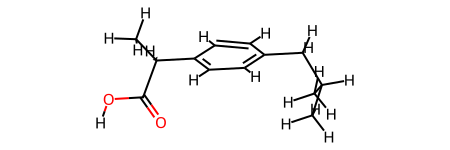

In [3]:
from rdkit import Chem
import pandas as pd

mol = Chem.MolFromMolFile("molecule_2.sdf.sdf", removeHs=False)
Chem.MolToPDBFile(mol, "output.pdb")
mol


**7. You can display a list of molecules from their smiles**

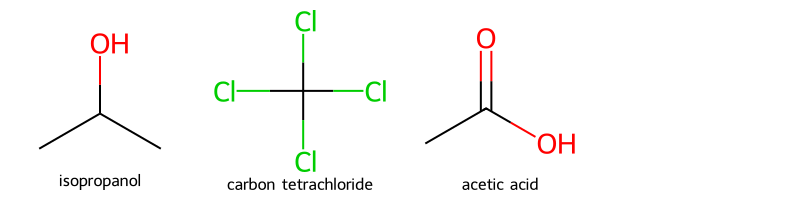

In [4]:
from rdkit.Chem.Draw import MolsToGridImage

smiles_list = [["C(C)(C)O", 'isopropanol'],
 ['C(Cl)(Cl)(Cl)Cl', 'carbon tetrachloride'],
 ['CC(=O)O', 'acetic acid']]

def display_structures(smiles_list):
    mol_list = []
    name_list = []
    for smiles, name in smiles_list:
        mol_list.append(Chem.MolFromSmiles(smiles))
        name_list.append(name)
    return MolsToGridImage(mol_list,legends=name_list,molsPerRow=4)
display_structures(smiles_list)

**8. How do you ensure uniqueness in your molecules (Canonical smiles)**

In [5]:
#you convert to mol 
pentane_smiles_list = ["CCCCC","C(CCCC)","C-C-C-C-C","[CH3][CH2][CH2][CH2][CH3]","CC(CCC)"]
pentane_mol_list = [Chem.MolFromSmiles(x) for x in pentane_smiles_list]
pentane_mol_list

In [6]:
#Then convert back to smiles to get the canonical smiles
canonical_smiles_list = [Chem.MolToSmiles(x) for x in pentane_mol_list]
pd.Series(canonical_smiles_list).unique()

array(['CCCCC'], dtype=object)

**9. Finally, you can use SMARTS pattern to find patterns in strucutural database**

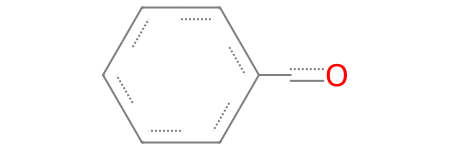

In [8]:
#To use SMARTS patterns, you can use the following code snippet:

from rdkit import Chem
from rdkit.Chem import Draw

mol = Chem.MolFromSmarts("c1ccccc1[#8]")
mol

**Special thanks to resources provided by [Pat Walters](https://github.com/PatWalters/practical_cheminformatics_tutorials) and the main [RDKit Page](https://rdkit.org/docs/GettingStartedInPython.html)**

In [1]:
import pandas as pd

data = pd.read_csv("filtered_drugbank_actives.csv")
smiles_list = data["smiles"].tolist()
with open("library.smi", "w") as f:
    for i, smi in enumerate(smiles_list, start=1):
        f.write(f"{smi} mol{i}\n")